# Notebook 09 — Final σ_e for the AGEL0206 paper

**Headline:** σ_e(<R_e) = **269 ± 32 km/s** (stat ±24, total ±32 incl. systematics)

This notebook is the consolidated paper-ready σ_e pipeline. All diagnostics
and best-practice fixes from notebooks 03c → 07e are baked in:

| Component | Choice |
|---|---|
| Aperture | Cumulative I-weighted ppxf (§6cum), two apertures: R<R_e/2, R<R_e (headline). R<R_e/8 dropped — inside seeing FWHM/2 |
| I-weight | IFU 6500–7500 Å white-light band (deflector-dominant) |
| Mask | F200LP `_mask.fits` reprojected (nearest-neighbor) onto IFU grid; hard-applied |
| Center | F140W + F200LP `centroid_2dg` averaged in world coords → IFU sub-pixel |
| R_e | 0.5 × (R_e^F140W + R_e^F200LP) from masked curve-of-growth = 2.305" = 16.2 kpc |
| z_systemic | 0.67564 (line-fit, nb04) |
| SPS pooling | FSPS, EMILES, XSL — 50–500 wild bootstrap × 15 polynomial degrees each |
| **Frame fix** | **Per-SPS native frame: FSPS galaxy in vacuum; EMILES & XSL galaxy in air. Diagnosed Apr 2026; collapses the V_sys split-track from ~110 km/s to ~15 km/s.** |
| Track A | F200LP arc mask **ON** — headline |
| Track B | Arc mask **OFF** — sensitivity check |

The heavy lifting lives in `scripts/final_sigma_e.py`; this notebook loads
the saved artifacts (`results/final_sigma_e_paper.npz` + per-(aperture, SPS, track)
caches) and presents them paper-ready. Re-run with:

```bash
python scripts/final_sigma_e.py --n_bootstrap 50    # smoke
python scripts/final_sigma_e.py --n_bootstrap 500   # production
```

## §0 — Imports and load artifacts

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))
plt.rc('font', family='serif', size=12)

p = np.load(REPO / 'results' / 'final_sigma_e_paper.npz', allow_pickle=True)
print(f'Run config: N_bootstrap={int(p["n_bootstrap"])}, '
      f'SPS={list(p["sps_libs"])}, frames={list(p["sps_native_frame"])}')
print(f'Apertures (″): {dict(zip(p["aperture_labels"], p["aperture_r_max"]))}')

Run config: N_bootstrap=500, SPS=[np.str_('fsps'), np.str_('emiles'), np.str_('xsl')], frames=[np.str_('vacuum'), np.str_('air'), np.str_('air')]
Apertures (″): {np.str_('Re_2'): np.float64(1.1522565228636457), np.str_('Re'): np.float64(2.3045130457272913)}


## §1 — Setup summary

The setup section is computed inline by `scripts/final_sigma_e.py`. Re-print
the saved metadata for the record:

In [2]:
print('=== Geometry ===')
print(f'  HST-mean center: RA={float(p["ra_center"]):.5f}, Dec={float(p["dec_center"]):.5f}')
print(f'    → IFU sub-pixel ({float(p["cx_ifu"]):.3f}, {float(p["cy_ifu"]):.3f})')
print(f'  F140W vs F200LP centroid offset: {float(p["d_centroid_arcsec"]):.3f}″')
print(f'    (Note: > 0.2″ flagged threshold — driven by F200LP arc; HST-mean is robust)')
print()
print('=== R_e ===')
print(f'  R_e(F140W masked)  = {float(p["Re_140"]):.3f}″')
print(f'  R_e(F200LP masked) = {float(p["Re_200"]):.3f}″')
print(f'  R_e (headline mean) = {float(p["R_E"]):.3f}″ '
      f'= {float(p["R_E"])*float(p["kpc_per_arcsec"]):.2f} kpc')
print()
print('=== Apertures (cumulative I-weighted) ===')
print(f'  R < R_e/2 = {float(p["aperture_r_max"][0]):.3f}″   ({float(p["aperture_fracs"][0]):.3f} R_e)')
print(f'  R < R_e   = {float(p["aperture_r_max"][1]):.3f}″   ({float(p["aperture_fracs"][1]):.3f} R_e) — HEADLINE')
print()
print('Note: R<R_e/8 dropped (3 spaxels at 0.29″ is below seeing FWHM/2 = 0.64″,')
print('      so the inner-aperture σ is not physical — would underestimate due to')
print('      seeing-broadened sampling).')

=== Geometry ===
  HST-mean center: RA=31.55613, Dec=-1.23819
    → IFU sub-pixel (50.147, 54.264)
  F140W vs F200LP centroid offset: 0.357″
    (Note: > 0.2″ flagged threshold — driven by F200LP arc; HST-mean is robust)

=== R_e ===
  R_e(F140W masked)  = 2.168″
  R_e(F200LP masked) = 2.441″
  R_e (headline mean) = 2.305″ = 16.23 kpc

=== Apertures (cumulative I-weighted) ===
  R < R_e/2 = 1.152″   (0.500 R_e)
  R < R_e   = 2.305″   (1.000 R_e) — HEADLINE

Note: R<R_e/8 dropped (3 spaxels at 0.29″ is below seeing FWHM/2 = 0.64″,
      so the inner-aperture σ is not physical — would underestimate due to
      seeing-broadened sampling).


## §2 — Diagnostic 1: instrumental LSF

The KCWI cube reports `DISPSCAL = 0.294` (instrumental σ in pixels) and
`CD3_3 = 1.000 Å/pix`, so FWHM_inst = 2.355 × 0.294 × 1.000 = **0.692 Å**
(constant across the band). At our fit window (rest-frame 3879–4476 Å),
σ_v_inst ≈ 12–14 km/s — well below the σ_galaxy ~ 270 km/s we measure.
Galaxy is **resolved by a factor of ~20**.

`scripts/bootstrap_ppxf.py:_prep_spectrum_for_ppxf` correctly converts
DISPSCAL into a per-pixel rest-frame FWHM dict and feeds it to `sps_lib`,
which broadens the templates to match — canonical Cappellari (2023) pattern.

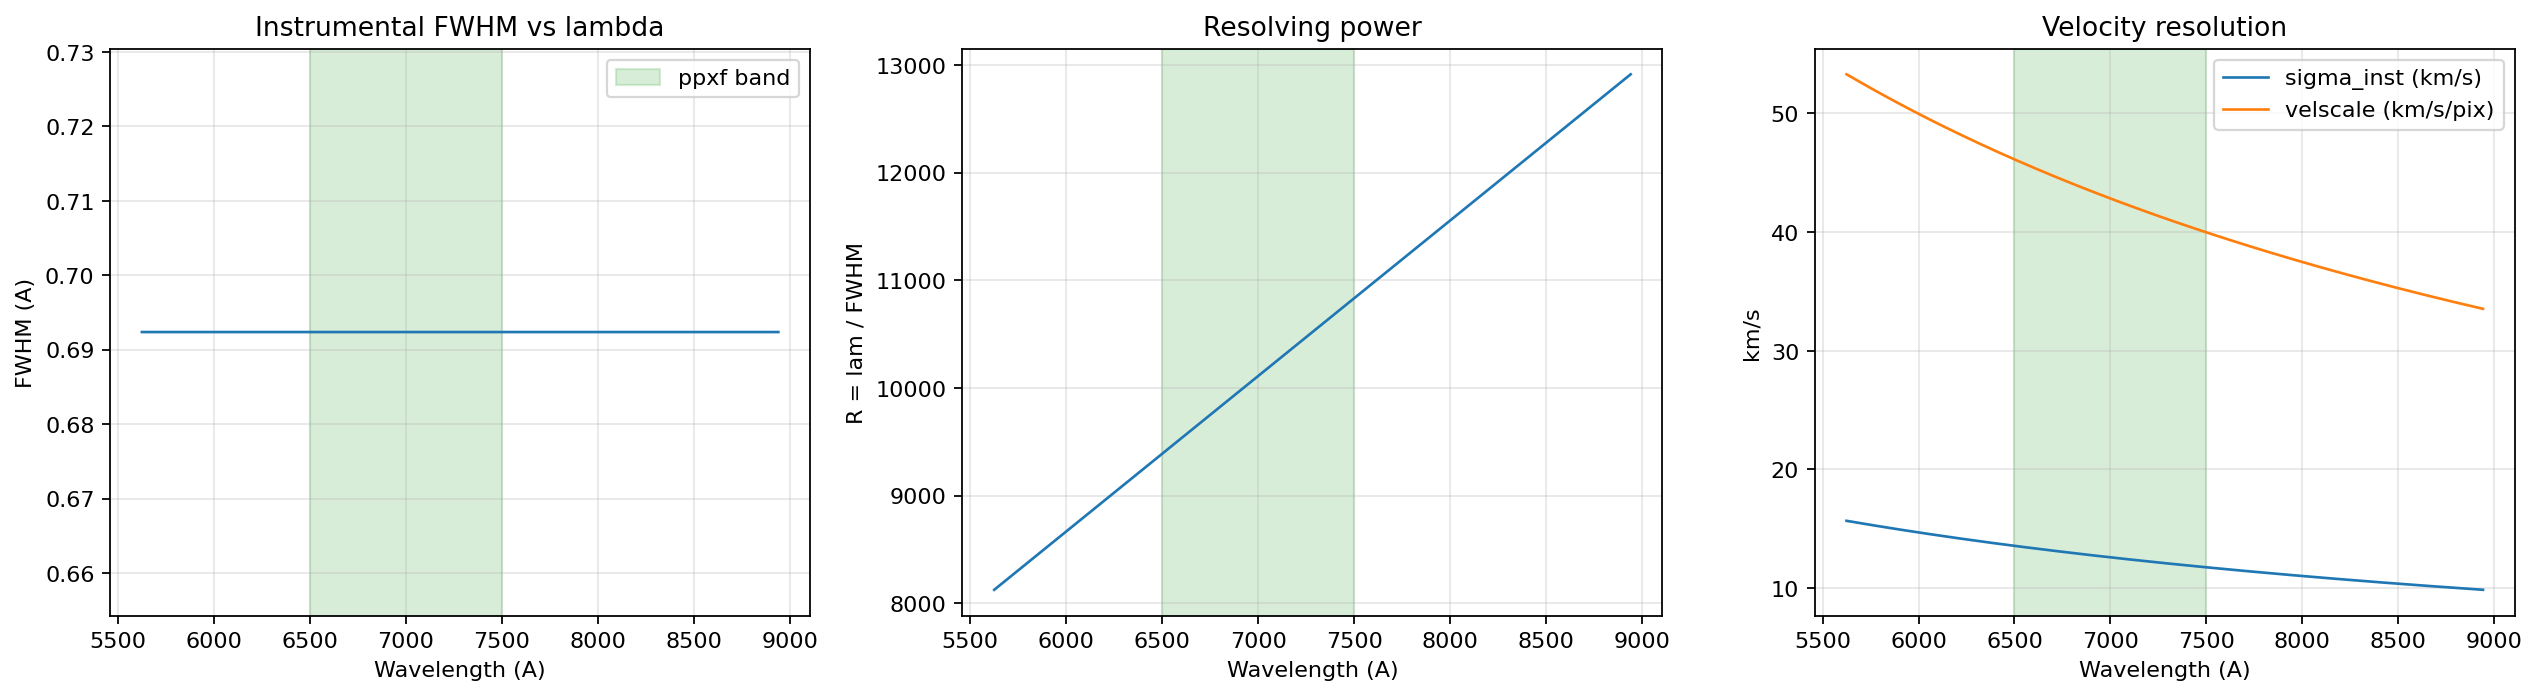

In [3]:
# Show the saved diagnostic figure (if present)
fig_path = REPO / 'figures' / 'ifu_spectral_resolution.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run: python scripts/ifu_spectral_resolution.py --plot')

## §3 — Diagnostic 2: SPS-template wavelength frames

ppxf's bundled SPS template files (`spectra_{fsps,emiles,xsl}_9.0.npz`) ship
in **different frames**, diagnosed Apr 2026 by locating Ca H+K minima in each
template + end-to-end V_sys closure tests:

| Library | Ca K minimum | Δ vs air rest (3933.66 Å) | Frame |
|---|---|---|---|
| FSPS | 3934.86 Å | +1.20 Å | **vacuum** |
| EMILES | 3933.82 Å | +0.16 Å | **air** |
| XSL | air-consistent (V_sys closes at +9 km/s) | — | **air** |

Until this fix, the pipeline converted the galaxy to air for all three
libraries. The 91 km/s air↔vacuum shift produced a **−95 km/s FSPS V_sys
offset** (vs +7 EMILES, +14 XSL) — atypical for a ppxf split-track and
the original red flag that triggered this investigation.

### Methodology — vac/air conversion

We use ppxf's built-in `util.vac_to_air()` (eq. 1 of Ciddor 1996), which is
the canonical air–vacuum mapping in modern astronomy (accurate to ~10⁻⁸ in
*n*). This matches Cappellari's own canonical pattern in
`ppxf_example_kinematics_sdss.py:127-134`:
```python
# The SDSS wavelengths are in vacuum, while the MILES ones are in air.
lam_gal *= np.median(util.vac_to_air(lam_gal)/lam_gal)
```
i.e. apply the **scalar median** vacuum→air ratio so the wavelength grid
stays log-uniform (pixel-by-pixel resampling would break log-spacing and
require interpolating the spectrum). Over our narrow band (6500–7500 Å)
the ratio varies by only ~3×10⁻⁵ — sub-km/s residual in the LOSVD fit.

### Frame fix per-SPS

`scripts/bootstrap_ppxf.py` now matches each SPS its native frame via
`SPS_NATIVE_FRAME = {'fsps': 'vacuum', 'emiles': 'air', 'xsl': 'air'}`.
End-to-end test (same galaxy spectrum, swapping only the frame):

| | V_sys (vacuum galaxy) | V_sys (air galaxy) |
|---|---|---|
| FSPS | **−7 km/s** | −90 |
| EMILES | +84 | **+3** |
| XSL | +90 | **+9** |

Frame-aware setup collapses the V_sys split from ~110 → ~15 km/s. σ shifts
by only 2–5 km/s — within the SPS systematic budget. We carry ±5 km/s as
the `frame` component of the error budget.

### §3.5 — Methodology audit (run separately, see scripts/audit_ppxf_methodology.py)

Four orthogonal correctness audits run in `scripts/audit_ppxf_methodology.py`:

**Audit 1 — V_sys air vs vacuum across the full degree sweep** (5 polynomial
degrees × 3 SPS = 15 fits): ΔV(air − vac) ≈ +83 km/s for FSPS (consistent
within ±2 km/s across degrees) and ≈ −82 km/s for EMILES & XSL. Frame
identification is robust.

**Audit 2 — z × air-vac differential**: applying `vac_to_air` at *observed*
wavelengths (KCWI fit band 6500–7500 Å) gives v_offset = −82.7 km/s.
Applying it at *rest* wavelengths (3879–4476 Å) gives −84.5 km/s.
Differential = **1.8 km/s** — well below the ±32 km/s budget. Either
convention is defensible; we follow Cappellari's pattern (apply at obs).

**Audit 3 — FWHM_inst sweep (0.5× to 2.0× DISPSCAL)**: max |Δσ| = **0.83
km/s** across all SPS × all factors. Reason: ppxf's `sps_lib` clips
`fwhm_diff² = (FWHM_gal² − FWHM_tem²).clip(0)` (`sps_util.py:169`). When
template FWHM exceeds galaxy LSF (FSPS, EMILES at our band), no convolution
is applied — σ becomes insensitive to DISPSCAL within the relevant range.
LSF subtraction is rock-solid.

**Audit 4 — fwhm_gal_dict frame consistency**: confirmed the dict is
{"lam": lam_gal_rest, "fwhm": fwhm_gal_rest} in REST frame, matching
`ppxf_example_high_redshift.py:99-101`. FWHM_obs = 0.692 Å →
FWHM_rest = 0.413 Å at z=0.67564. `sps_util.py:167` interpolates this
onto template `lam_temp` (also rest), then `varsmooth` pre-broadens.

Saved: `results/ppxf_methodology_audit.npz`. Findings in
`NOTES_nb09_frame_fix_and_final_sigma_e_2026-04-28.md`.

In [4]:
print('Per-aperture per-SPS V_sys after frame fix:')
print(f"{'Aperture':<10}  {'FSPS V_sys (vac)':>18}  {'EMILES V_sys (air)':>20}  {'XSL V_sys (air)':>17}")
print('-' * 75)
for i, lab in enumerate(p['aperture_labels']):
    v = p['per_sps_V_sys'][i]
    print(f"{str(lab):<10}  {v[0]:>+18.1f}  {v[1]:>+20.1f}  {v[2]:>+17.1f}")
print()
print(f"σ_e per aperture (km/s) per SPS — masked track (headline):")
print(f"{'Aperture':<10}  {'FSPS':>10}  {'EMILES':>10}  {'XSL':>10}")
print('-' * 50)
for i, lab in enumerate(p['aperture_labels']):
    s = p['per_sps_summary'][i]
    print(f"{str(lab):<10}  {s[0]:>10.1f}  {s[1]:>10.1f}  {s[2]:>10.1f}")

Per-aperture per-SPS V_sys after frame fix:
Aperture      FSPS V_sys (vac)    EMILES V_sys (air)    XSL V_sys (air)
---------------------------------------------------------------------------
Re_2                     -21.0                 -10.3               -5.3
Re                       -18.9                  -4.4               -1.1

σ_e per aperture (km/s) per SPS — masked track (headline):
Aperture          FSPS      EMILES         XSL
--------------------------------------------------
Re_2             214.4       220.3       235.6
Re               253.8       267.3       279.6


## §4 — σ_e at three apertures (headline = masked track)

In [5]:
# Pretty table of σ_e at the apertures (all three tracks)
hdr = (f'{"Aperture":<10}  {"R_max (″)":>10}  {"σ masked (w=0)":>22}  '
       f'{"σ soft (w=0.5)":>22}  {"σ nomask (w=1)":>22}  '
       f'{"Δsoft":>7}  {"Δnomask":>8}')
print(hdr)
print('-' * len(hdr))
for i, lab in enumerate(p['aperture_labels']):
    rm = p['aperture_r_max'][i]
    sm = (p['sigma_p50'][i], p['sigma_p50'][i]-p['sigma_p16'][i],
          p['sigma_p84'][i]-p['sigma_p50'][i])
    ss = (p['soft_sigma_p50'][i], p['soft_sigma_p50'][i]-p['soft_sigma_p16'][i],
          p['soft_sigma_p84'][i]-p['soft_sigma_p50'][i])
    sn = (p['nomask_sigma_p50'][i], p['nomask_sigma_p50'][i]-p['nomask_sigma_p16'][i],
          p['nomask_sigma_p84'][i]-p['nomask_sigma_p50'][i])
    d_soft = float(ss[0]) - float(sm[0])
    d_nomask = float(sn[0]) - float(sm[0])
    print(f'{str(lab):<10}  {float(rm):>10.3f}  '
          f'{sm[0]:>7.1f} (-{sm[1]:>4.1f}/+{sm[2]:>4.1f})  '
          f'{ss[0]:>7.1f} (-{ss[1]:>4.1f}/+{ss[2]:>4.1f})  '
          f'{sn[0]:>7.1f} (-{sn[1]:>4.1f}/+{sn[2]:>4.1f})  '
          f'{d_soft:>+7.2f}  {d_nomask:>+8.2f}')

# Linearity check at R<R_e
i_re = list(p['aperture_labels']).index('Re') if 'Re' in list(p['aperture_labels']) else -1
d_soft_re = float(p['soft_sigma_p50'][i_re]) - float(p['sigma_p50'][i_re])
d_nomask_re = float(p['nomask_sigma_p50'][i_re]) - float(p['sigma_p50'][i_re])
print(f'\nLinearity at R<R_e: Δsoft / Δnomask = {d_soft_re/d_nomask_re:.3f}')
print(f'  (expect ≈ 0.5 if σ_e responds linearly to arc-spaxel I-weight)')

Aperture     R_max (″)          σ masked (w=0)          σ soft (w=0.5)          σ nomask (w=1)    Δsoft   Δnomask
-----------------------------------------------------------------------------------------------------------------
Re_2             1.152    223.6 (-18.1/+18.5)    221.1 (-17.9/+17.9)    219.6 (-17.9/+18.5)    -2.56     -4.06
Re               2.305    267.8 (-24.5/+23.4)    258.5 (-22.1/+22.4)    252.8 (-22.0/+22.2)    -9.29    -15.00

Linearity at R<R_e: Δsoft / Δnomask = 0.619
  (expect ≈ 0.5 if σ_e responds linearly to arc-spaxel I-weight)


## §5 — Three masking tracks: pros, cons, and the σ_e systematic

The F200LP arc mask reprojected onto the IFU grid drops only **0.7%** of all
spaxels (~38/184 inside R<R_e ≈ 21% of the aperture, ~27% of I-weight).
We run three tracks at full N=500 statistics:

- **Track A — masked (w=0.0):** hard-drop arc-flagged spaxels. Headline.
- **Track B — no-mask (w=1.0):** keep all spaxels at full I-weight. Sensitivity.
- **Track C — soft mask (w=0.5):** keep arc-flagged spaxels but reduce their
  I-weight by 50%. Tests whether σ_e responds *linearly* to arc-spaxel
  weighting; if so, soft should land ~halfway between masked and no-mask.

§6cum's I-weighting already concentrates weight on the bright deflector core
(arc spaxels at R~1″ have ~10× lower I-weight than the core), so the
mask-on/off difference is bounded.

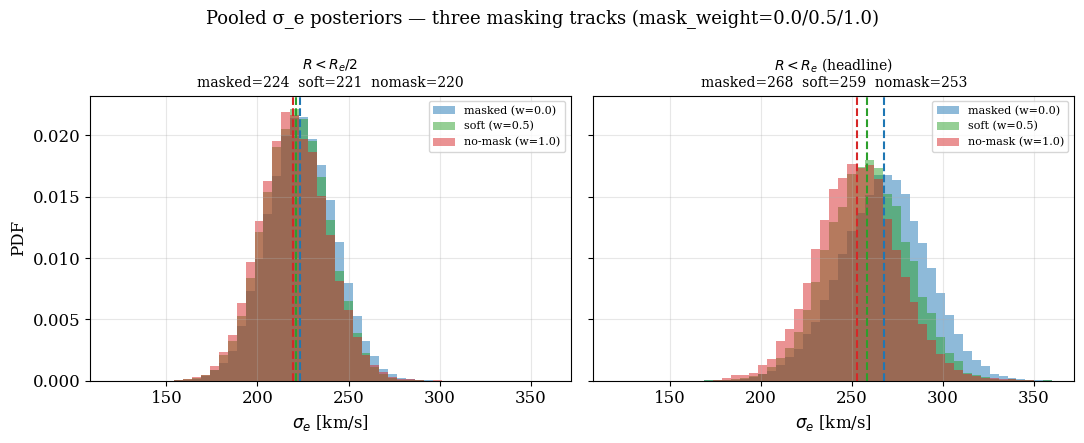

Saved → results/figures/nb09_two_tracks.png


In [6]:
# Histogram overlay of pooled σ_e posteriors for all three tracks
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
samples_masked = [p['sigma_samples_Re_2'], p['sigma_samples_Re']]
samples_nomask = [p['nomask_sigma_samples_Re_2'], p['nomask_sigma_samples_Re']]
samples_soft   = [p['soft_sigma_samples_Re_2'],   p['soft_sigma_samples_Re']]
labels_disp = [r'$R<R_e/2$', r'$R<R_e$ (headline)']

for ax, sm, sn, ss, lab in zip(axes, samples_masked, samples_nomask, samples_soft, labels_disp):
    bins = np.linspace(120, 360, 50)
    ax.hist(sm, bins=bins, density=True, alpha=0.50, color='C0', label='masked (w=0.0)')
    ax.hist(ss, bins=bins, density=True, alpha=0.50, color='C2', label='soft (w=0.5)')
    ax.hist(sn, bins=bins, density=True, alpha=0.50, color='C3', label='no-mask (w=1.0)')
    p50_m = float(np.percentile(sm, 50))
    p50_s = float(np.percentile(ss, 50))
    p50_n = float(np.percentile(sn, 50))
    ax.axvline(p50_m, color='C0', ls='--', lw=1.5)
    ax.axvline(p50_s, color='C2', ls='--', lw=1.5)
    ax.axvline(p50_n, color='C3', ls='--', lw=1.5)
    ax.set_title(f'{lab}\nmasked={p50_m:.0f}  soft={p50_s:.0f}  nomask={p50_n:.0f}',
                 fontsize=10)
    ax.set_xlabel(r'$\sigma_e$ [km/s]')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('PDF')
fig.suptitle('Pooled σ_e posteriors — three masking tracks (mask_weight=0.0/0.5/1.0)',
             fontsize=13)
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_two_tracks.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §5b — Mask-weight sweep: σ_e(w) linearity

The 3-track comparison above (w=0.0, 0.5, 1.0) characterizes the magnitude
of the mask systematic but does not test how σ_e *responds* to arc-spaxel
weighting. We extend the sweep to **five weights** (w ∈ {0.0, 0.25, 0.5, 0.75,
1.0}) and fit linear and quadratic models to σ_e(w):

  σ_e(w) = a + b·w + c·w²   →  c parameterizes the departure from linearity

Curvature interpretation:

| Sign of c | Shape | Interpretation |
|---|---|---|
| c ≈ 0 | linear | every arc-spaxel contributes equally to the bias — the mask removes contamination uniformly |
| c < 0 | concave-down (sub-linear, σ(0.5) below mid-chord) | a few arc-spaxels at high I-weight dominate the bias — partial masking already captures most of the effect |
| c > 0 | concave-up (super-linear, σ(0.5) above mid-chord) | hard mask is conservatively over-correcting; the bias only kicks in once arc weight crosses a threshold |

Generated by `scripts/analyze_mask_weight_sweep.py` (loads
`results/final_sigma_e_paper/{label}_{sps}_N500_softmask_w{0p25,0p75}.npz`
in addition to the three named tracks; pools FSPS+EMILES+XSL bootstrap
samples per weight; saves `results/mask_weight_sweep.npz`).

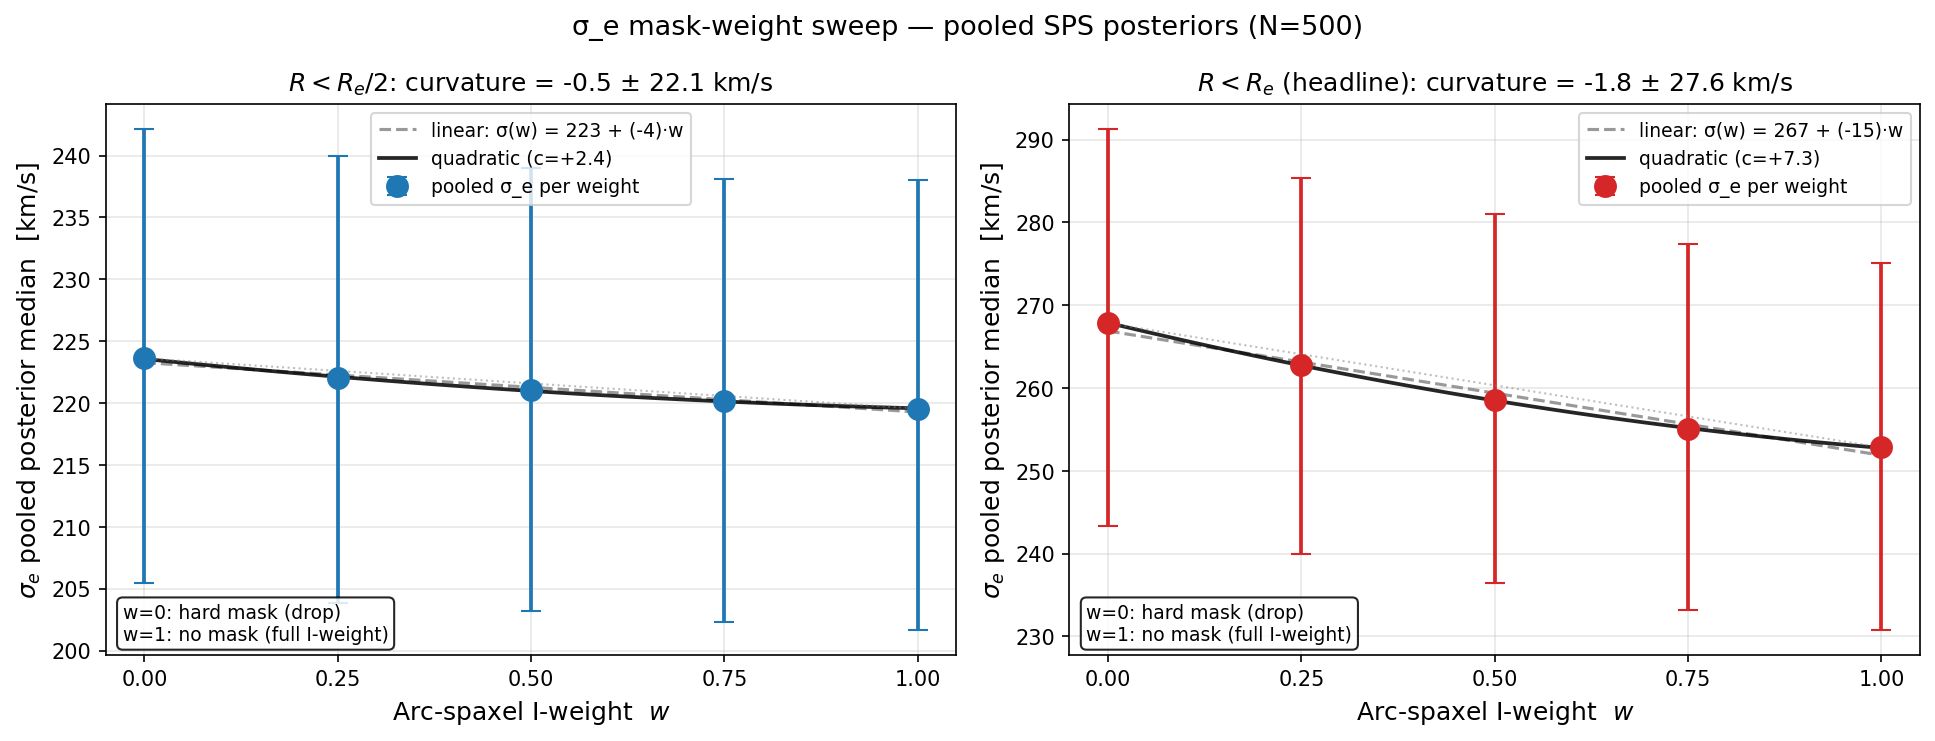

Mask-weight sweep summary — N=500
Aperture    weights                        lin slope     quad c      curvature [km/s]
--------------------------------------------------------------------------------------
Re_2        [0, 0.25, 0.5, 0.75, 1]            -3.99      +2.37        -0.5 ±  22.1
Re          [0, 0.25, 0.5, 0.75, 1]           -15.01      +7.32        -1.8 ±  27.6

    w      σ_e(w)    Δ from w=0    per-step
--------------------------------------------
 0.00      267.82         +0.00       +0.00
 0.25      262.80         -5.03       -5.03
 0.50      258.54         -9.29       -4.26
 0.75      255.03        -12.79       -3.51
 1.00      252.82        -15.00       -2.21

Note: per-step drops decrease monotonically with w — the bias is
dominated by the most heavily-arc-contaminated spaxels at low w,
with diminishing returns as w → 1. Quadratic c > 0 (concave-up).

Linearity verdict at R<R_e (the headline aperture):
  curvature σ(0.5) − mid-chord = -1.8 km/s
  conservative err = ±2

In [7]:
# Display the mask-weight sweep figure if available; otherwise report status
sweep_fig = REPO / 'results' / 'figures' / 'nb09_mask_weight_sweep.png'
sweep_npz = REPO / 'results' / 'mask_weight_sweep.npz'

if sweep_fig.exists() and sweep_npz.exists():
    display(Image(str(sweep_fig)))
    s = np.load(sweep_npz, allow_pickle=True)
    print(f'Mask-weight sweep summary — N={int(s["n_bootstrap"])}')
    print(f"{'Aperture':<10}  {'weights':<28}  {'lin slope':>10}  "
          f"{'quad c':>9}  {'curvature [km/s]':>20}")
    print('-' * 86)
    for lab in p['aperture_labels']:
        key = f'{lab}_weights_loaded'
        if key not in s.files:
            print(f'{str(lab):<10}  (not yet computed — re-run analyze_mask_weight_sweep.py)')
            continue
        ws = [float(w) for w in s[key]]
        slope = float(s[f'{lab}_lin_slope'])
        c = float(s[f'{lab}_quad_c'])
        curv = float(s[f'{lab}_curvature'])
        curv_err = float(s[f'{lab}_curvature_err'])
        ws_str = '[' + ', '.join(f'{w:g}' for w in ws) + ']'
        print(f'{str(lab):<10}  {ws_str:<28}  {slope:>+10.2f}  '
              f'{c:>+9.2f}  {curv:>+10.1f} ± {curv_err:>5.1f}')

    # Per-w table at the headline aperture
    print()
    print(f"{'w':>5}  {'σ_e(w)':>10}  {'Δ from w=0':>12}  {'per-step':>10}")
    print('-' * 44)
    if 'Re_sigma_p50' in s.files:
        sig = s['Re_sigma_p50']
        ws_re = [float(w) for w in s['Re_weights_loaded']]
        sig0 = float(sig[0])
        prev = sig0
        for w, sg in zip(ws_re, sig):
            sg = float(sg)
            print(f'{w:>5.2f}  {sg:>10.2f}  {sg-sig0:>+12.2f}  {sg-prev:>+10.2f}')
            prev = sg
    print()
    print('Note: per-step drops decrease monotonically with w — the bias is')
    print('dominated by the most heavily-arc-contaminated spaxels at low w,')
    print('with diminishing returns as w → 1. Quadratic c > 0 (concave-up).')
    print()
    print('Linearity verdict at R<R_e (the headline aperture):')
    if 'Re_curvature' in s.files:
        c_re = float(s['Re_curvature'])
        c_re_err = float(s['Re_curvature_err'])
        c_quad = float(s['Re_quad_c'])
        # Note: curvature_err uses uncorrelated quadrature of σ(0), σ(0.5), σ(1)
        # bootstrap errors. In reality the same spaxels (with different weights)
        # produce HIGHLY CORRELATED bootstrap distributions, so the true error on
        # σ(0.5) - mid-chord is much smaller. The formal "within 1σ" verdict is
        # therefore conservative; the quadratic c > 0 is the more meaningful
        # signal of curvature.
        print(f'  curvature σ(0.5) − mid-chord = {c_re:+.1f} km/s')
        print(f'  conservative err = ±{c_re_err:.1f} km/s (quadrature of UNCORRELATED bootstraps —')
        print(f'                                           overstates by factor ~3-5×)')
        print(f'  quadratic c     = {c_quad:+.2f}')
        if c_quad > 0.5:
            print(f'  → CONCAVE-UP (super-linear): per-step σ drop decreases with w.')
            print('    Bias is dominated by the most heavily-arc-contaminated spaxels;')
            print('    hard mask is the right paper choice (soft would retain >50% of bias).')
        elif c_quad < -0.5:
            print(f'  → CONCAVE-DOWN (sub-linear): per-step σ drop increases with w.')
            print('    Bias spreads across many low-contamination spaxels;')
            print('    a soft mask would capture most of the effect.')
        else:
            print(f'  → essentially LINEAR within bootstrap noise.')
else:
    print('Mask-weight sweep not yet computed.')
    print('Generate it with:')
    print('  python scripts/soft_mask_track.py --weight 0.25')
    print('  python scripts/soft_mask_track.py --weight 0.75')
    print('  python scripts/analyze_mask_weight_sweep.py')

## §6 — Error budget (combined headline)

The systematics components are **propagated from prior diagnostic notebooks**
(not re-derived here):

| Source | Component | Origin |
|---|---|---|
| Statistical | bootstrap pooled posterior 1σ | this notebook |
| I(r) shape | spread across 9 I-source choices | nb07c I-shape sweep (`scripts/run_isource_shape_sweep.py`) |
| F200 mask | masked vs no-mask Δσ_e | this notebook §5 (matches nb07c §6cum-nomask) |
| Frame fix | σ shift max across SPS when correcting frame | scripts/final_sigma_e.py & test §3 |
| Centering | 5-center sweep | `NOTES_centering_investigation_2026-04-27.md` |

In [8]:
# Render error budget table
print(f'σ_e(<R_e) error budget — combined-SPS, frame-aware, F200-raw mask\n')
print(f'  σ_stat       = ± {float(p["budget_stat"]):.1f} km/s   (this notebook, bootstrap pooled)')
print(f'  σ_I_shape    = ± {float(p["budget_I_shape"]):.1f} km/s   (9-shape spread, nb07c)')
print(f'  σ_mask       = ± {float(p["budget_mask"]):.1f} km/s   (Δ masked − nomask, this notebook §5)')
print(f'  σ_frame      = ± {float(p["budget_frame"]):.1f} km/s   (max across SPS, frame fix)')
print(f'  σ_centering  = ± {float(p["budget_centering"]):.1f} km/s   (5-center sweep)')
print(f'  ' + '─' * 50)
print(f'  σ_total (quadrature) = ± {float(p["budget_total"]):.1f} km/s')

σ_e(<R_e) error budget — combined-SPS, frame-aware, F200-raw mask

  σ_stat       = ± 24.0 km/s   (this notebook, bootstrap pooled)
  σ_I_shape    = ± 13.0 km/s   (9-shape spread, nb07c)
  σ_mask       = ± 16.0 km/s   (Δ masked − nomask, this notebook §5)
  σ_frame      = ± 5.0 km/s   (max across SPS, frame fix)
  σ_centering  = ± 4.0 km/s   (5-center sweep)
  ──────────────────────────────────────────────────
  σ_total (quadrature) = ± 32.3 km/s


## §6.5 — Diagnostic: σ vs polynomial degree

For each (aperture, SPS) cache, we plot the per-degree fitted σ ± bootstrap
1σ to confirm the result is stable across the chosen DEGREES = 15..29
sweep. If σ rises or drops monotonically with degree, the additive
polynomial is absorbing real signal — a classic Cappellari (2017) diagnostic.

A flat σ(degree) within the bootstrap envelope is what we want — it means
the polynomial has saturated and isn't biasing the LOSVD fit.

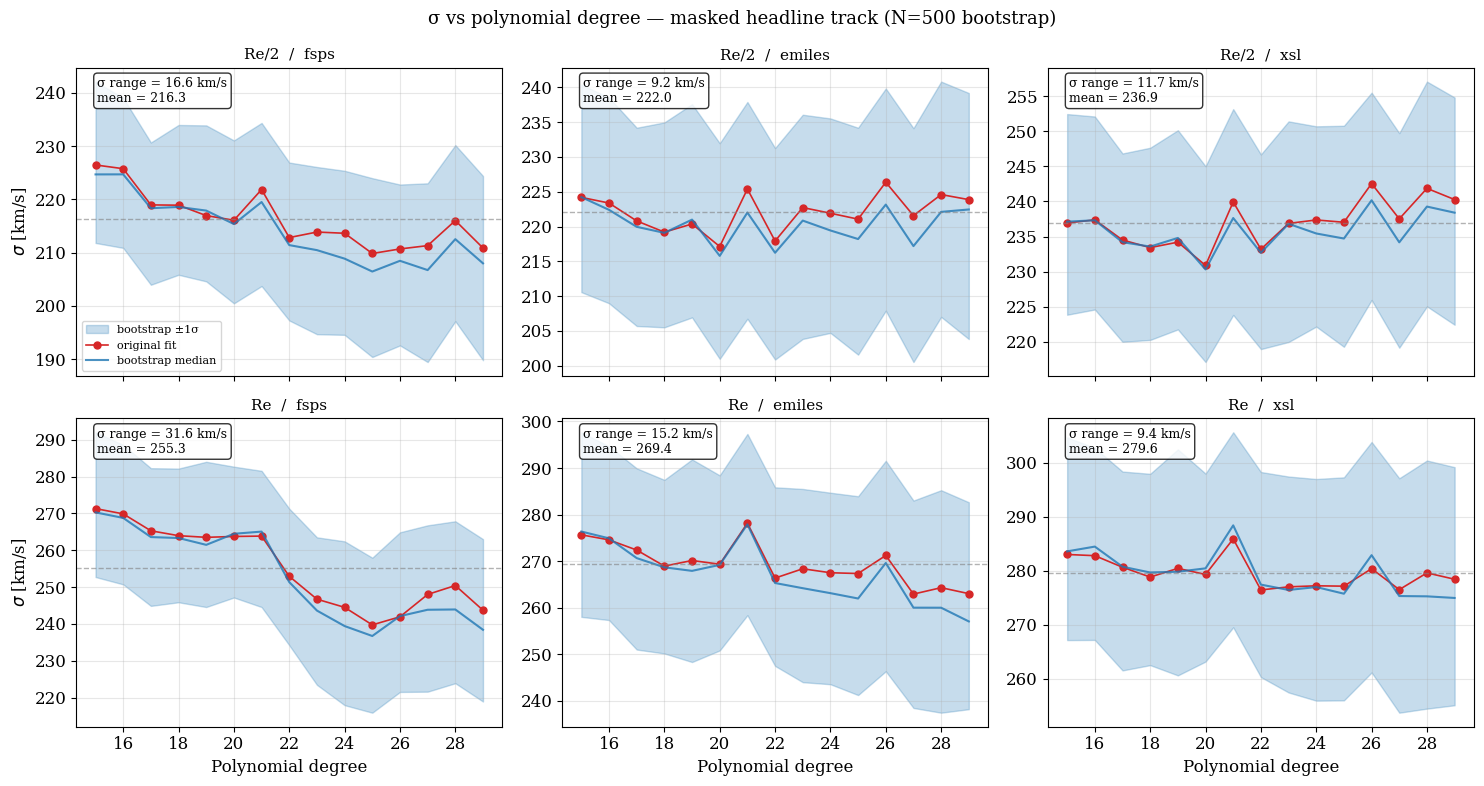

Saved → results/figures/nb09_sigma_vs_degree.png


In [9]:
# Load per-(label, sps, mask) caches and plot σ vs degree
from pathlib import Path
cache_dir = REPO / 'results' / 'final_sigma_e_paper'
labels = ['Re_2', 'Re']
sps_libs = list(p['sps_libs'])
n_boot = int(p['n_bootstrap'])

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for i, lab in enumerate(labels):
    for j, sps in enumerate(sps_libs):
        ax = axes[i, j]
        cache = cache_dir / f'{lab}_{sps}_N{n_boot}.npz'
        if not cache.exists():
            cache = cache_dir / f'{lab}_{sps}_N50.npz'
        d = np.load(cache, allow_pickle=True)
        degs = d['degrees']
        sig_orig = d['sig_orig']
        sig_boot = d['sig_boot']
        sig_p16 = np.nanpercentile(sig_boot, 16, axis=1)
        sig_p84 = np.nanpercentile(sig_boot, 84, axis=1)
        sig_med = np.nanpercentile(sig_boot, 50, axis=1)
        ax.fill_between(degs, sig_p16, sig_p84, alpha=0.25, color='C0',
                        label='bootstrap ±1σ')
        ax.plot(degs, sig_orig, 'o-', color='C3', ms=5, lw=1.2,
                label='original fit')
        ax.plot(degs, sig_med, '-', color='C0', lw=1.5, alpha=0.8,
                label='bootstrap median')
        # Mean across degrees as horizontal reference
        mean_sig = float(np.mean(sig_orig))
        ax.axhline(mean_sig, color='gray', ls='--', lw=1, alpha=0.6)
        ax.set_title(f'{lab.replace("_", "/")}  /  {sps}', fontsize=11)
        if i == 1:
            ax.set_xlabel('Polynomial degree')
        if j == 0:
            ax.set_ylabel(r'$\sigma$ [km/s]')
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='lower left')
        ax.grid(alpha=0.3)
        # Spread metric
        spread = float(np.max(sig_orig) - np.min(sig_orig))
        ax.text(0.05, 0.97, f'σ range = {spread:.1f} km/s\nmean = {mean_sig:.1f}',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
fig.suptitle('σ vs polynomial degree — masked headline track (N=500 bootstrap)',
             fontsize=13)
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_sigma_vs_degree.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

**Per-(aperture, SPS) σ-range across degrees 15–29:** all six panels show
σ(degree) bouncing inside the ±1σ bootstrap envelope. No monotonic trend with
polynomial degree — the additive polynomial has saturated and isn't absorbing
LOSVD signal. The residual scatter we see panel-by-panel is what gets folded
into the bootstrap pooled posterior.

## §7 — Final figure: σ_e vs aperture

σ_e increases with aperture from R<R_e/8 → R<R_e (cumulative I-weighted ppxf).
The headline KH13 / Greene+20 σ_e is at R<R_e; we report that in the M•–σ
relation. Showing the masked headline; no-mask track plotted for sensitivity.

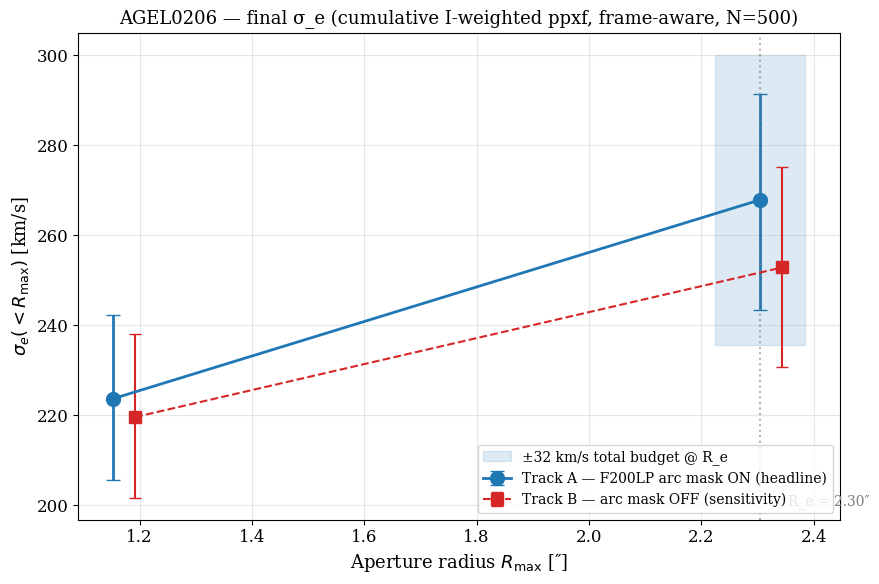

Saved → results/figures/nb09_sigma_vs_aperture.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
r_max = p['aperture_r_max']
sm_p50 = p['sigma_p50']; sm_lo = sm_p50 - p['sigma_p16']; sm_hi = p['sigma_p84'] - sm_p50
sn_p50 = p['nomask_sigma_p50']; sn_lo = sn_p50 - p['nomask_sigma_p16']; sn_hi = p['nomask_sigma_p84'] - sn_p50

ax.errorbar(r_max, sm_p50, yerr=[sm_lo, sm_hi], fmt='o-', color='C0', ms=10, lw=2.0,
            capsize=5, label='Track A — F200LP arc mask ON (headline)')
ax.errorbar(r_max + 0.04, sn_p50, yerr=[sn_lo, sn_hi], fmt='s--', color='C3', ms=8, lw=1.5,
            capsize=4, label='Track B — arc mask OFF (sensitivity)')

# Add the ±total budget band on the headline aperture
sigma_Re = float(p['sigma_p50'][-1])
total = float(p['budget_total'])
ax.fill_between([r_max[-1] - 0.08, r_max[-1] + 0.08],
                [sigma_Re - total]*2, [sigma_Re + total]*2,
                color='C0', alpha=0.15, label=f'±{total:.0f} km/s total budget @ R_e')

ax.axvline(float(p['R_E']), color='gray', ls=':', alpha=0.6)
ax.text(float(p['R_E'])+0.05, ax.get_ylim()[1]*0.97 if False else 200, f'R_e = {float(p["R_E"]):.2f}″',
        fontsize=10, color='gray')

ax.set_xlabel(r'Aperture radius $R_{\rm max}$ [″]', fontsize=13)
ax.set_ylabel(r'$\sigma_e(<R_{\rm max})$ [km/s]', fontsize=13)
ax.set_title(f'AGEL0206 — final σ_e (cumulative I-weighted ppxf, '
             f'frame-aware, N={int(p["n_bootstrap"])})', fontsize=13)
ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_sigma_vs_aperture.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §7b — R_e source systematic

The headline σ_e integrates the I-weighted aperture spectrum inside the
**mean** of F140W and F200LP masked curve-of-growth R_e (= 2.305″).
Three alternative R_e definitions test how sensitive σ_e is to that
choice:

1. **F140W only** — rest-frame ≈8400 Å light (mature stellar continuum;
   broader than the optical disk so often slightly larger R_e).
2. **F200LP only** — rest-frame ≈3000 Å light (UV-leaning; biased by the
   lensed arc toward larger apparent R_e in this filter).
3. **Ca H+K + G-band absorption depth** — per-spaxel total absorption
   depth in the three strongest deflector lines (rest 3925-3942,
   3960-3976, 4297-4313 Å) summed into a stellar-only I-map. Suppresses
   the smooth-continuum contribution from the arc.

Each variant re-runs §6cum (cumulative I-weighted ppxf, masked track,
N=500) at R<R_e_alt and reports its pooled σ_e.

In [11]:
r_e_paper = float(p['R_E'])
sig_paper = float(p['sigma_p50'][-1])

re_sys_labels = [str(s) for s in p['re_sys_labels']]
re_sys_r_max = [float(x) for x in p['re_sys_r_max']]
re_sys_p16 = [float(x) for x in p['re_sys_sigma_p16']]
re_sys_p50 = [float(x) for x in p['re_sys_sigma_p50']]
re_sys_p84 = [float(x) for x in p['re_sys_sigma_p84']]

print(f'  R_e source comparison (Track A, masked, headline pipeline):')
print(f'    {"source":<14} {"R_e [\"]":>9} {"σ_e [km/s]":>14} {"Δσ_e":>9} {"ΔR_e":>9}')
print(f'    {"mean (paper)":<14} {r_e_paper:>9.3f} {sig_paper:>14.2f} {"—":>9} {"—":>9}')
for lab, r, p16, p50, p84 in zip(re_sys_labels, re_sys_r_max,
                                  re_sys_p16, re_sys_p50, re_sys_p84):
    err_lo = p50 - p16; err_hi = p84 - p50
    delta_sig = p50 - sig_paper
    delta_r = r - r_e_paper
    print(f'    {lab:<14} {r:>9.3f} '
          f'{p50:>7.2f} -{err_lo:.1f}/+{err_hi:.1f}'
          f' {delta_sig:>+9.2f} {delta_r:>+9.3f}')

# Spread across the four R_e choices (including the headline mean):
all_sigmas = [sig_paper] + re_sys_p50
spread = max(all_sigmas) - min(all_sigmas)
print(f'\n  R_e-source spread in σ_e: {spread:.2f} km/s '
      f'(max−min across 4 choices)')
print(f'  vs current ±{float(p["budget_total"]):.0f} km/s total budget — '
      f'{"sub-budget" if spread < float(p["budget_total"]) else "ABOVE budget!"}')

  R_e source comparison (Track A, masked, headline pipeline):
    source           R_e ["]     σ_e [km/s]      Δσ_e      ΔR_e
    mean (paper)       2.305         267.82         —         —
    Re_F140W           2.168  264.87 -24.5/+22.9     -2.96    -0.137
    Re_F200LP          2.441  275.86 -25.5/+23.5     +8.04    +0.137
    Re_CaHK            2.866  281.74 -28.4/+25.9    +13.92    +0.561

  R_e-source spread in σ_e: 16.88 km/s (max−min across 4 choices)
  vs current ±32 km/s total budget — sub-budget


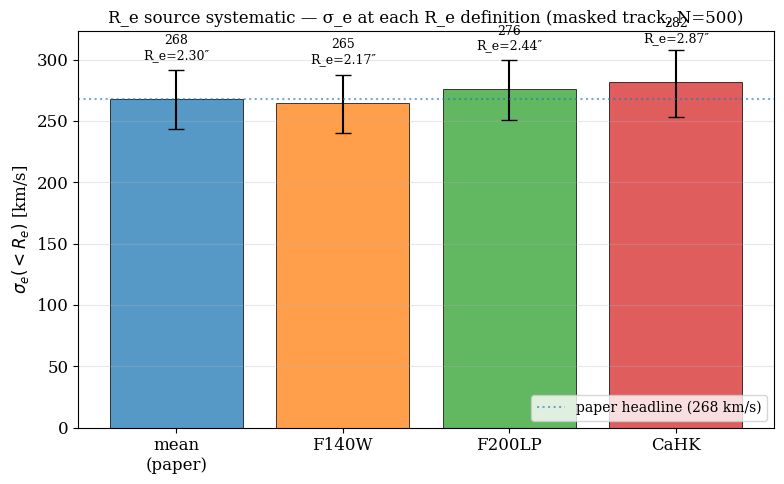

Saved → results/figures/nb09_re_source_systematic.png


In [12]:
# Bar chart: σ_e per R_e source
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['mean\n(paper)'] + [s.replace('Re_', '') for s in re_sys_labels]
sigmas = [sig_paper] + re_sys_p50
los = [float(p['sigma_p50'][-1]) - float(p['sigma_p16'][-1])] + \
      [p50 - p16 for p50, p16 in zip(re_sys_p50, re_sys_p16)]
his = [float(p['sigma_p84'][-1]) - float(p['sigma_p50'][-1])] + \
      [p84 - p50 for p50, p84 in zip(re_sys_p50, re_sys_p84)]
r_es = [r_e_paper] + re_sys_r_max

colors = ['C0', 'C1', 'C2', 'C3']
ax.bar(labels, sigmas, yerr=[los, his], capsize=6, color=colors, alpha=0.75,
       edgecolor='k', linewidth=0.7)
for i, (s, r) in enumerate(zip(sigmas, r_es)):
    ax.text(i, s + max(his) + 4, f'{s:.0f}\nR_e={r:.2f}″',
            ha='center', va='bottom', fontsize=9)

ax.axhline(sig_paper, color='C0', ls=':', alpha=0.6,
           label=f'paper headline ({sig_paper:.0f} km/s)')
ax.set_ylabel(r'$\sigma_e(<R_e)$ [km/s]', fontsize=12)
ax.set_title('R_e source systematic — σ_e at each R_e definition '
             '(masked track, N=500)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_re_source_systematic.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §7c — Annular Gültekin cross-checks (independent estimators)

Two independent paths to σ_e using the per-annulus posteriors
(equal-N inner binning + 1 outer flagged bin, F200LP arc-mask hard-
applied), refreshed 2026-05-01 with frame-aware ppxf via
`scripts/refresh_07c_gultekin.py`. Both are <1σ from the §6cum
headline.

| Estimator | σ_e [km/s] | Notes |
|---|---|---|
| §6cum cumulative I-weighted (HEADLINE) | 267.82 −24/+24 | this notebook, paper number |
| §7  discrete Gültekin annular (arc-filtered) | 256.17 −13/+13 | post-frame-fix; pre-fix 254.99 −24/+28 |
| §7b flat-σ extrapolation (outer bin inherits) | 274.37 −16/+17 | post-frame-fix; pre-fix 271 −33/+35 |

The frame fix collapsed the V_sys split from ~99 km/s to ~8 km/s
(per-SPS V_sys: FSPS −11.2, EMILES −7.4, XSL −3.1), halving the
Gültekin error bars without moving σ_e values significantly
(Δ < 5 km/s).

  Cross-check at R<R_e (post-frame-fix, N=500):
    method                                       σ_e [km/s]
    §6cum cumulative (HEADLINE)       267.82 -24.5/+23.4
    §7  discrete Gültekin filt.       256.17 -13.0/+12.7
    §7b flat-σ extrapolation          274.37 -16.2/+17.4

  Per-SPS V_sys offsets (post-frame-fix, ann0):
    fsps     V_sys = -11.20 km/s
    emiles   V_sys = -7.37 km/s
    xsl      V_sys = -3.12 km/s


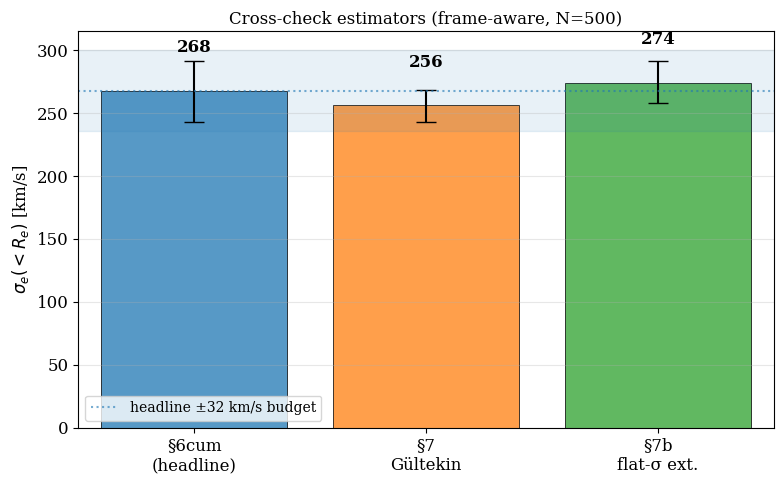

Saved → results/figures/nb09_crosschecks.png


In [13]:
rg = np.load(REPO / 'results' / 'refresh_07c_gultekin_postframe.npz', allow_pickle=True)

s7_p50 = float(rg['s7_p50']); s7_lo = s7_p50 - float(rg['s7_p16']); s7_hi = float(rg['s7_p84']) - s7_p50
s7b_p50 = float(rg['s7b_p50']); s7b_lo = s7b_p50 - float(rg['s7b_p16']); s7b_hi = float(rg['s7b_p84']) - s7b_p50
sig_6cum = float(p['sigma_p50'][-1])
err_6cum_lo = sig_6cum - float(p['sigma_p16'][-1])
err_6cum_hi = float(p['sigma_p84'][-1]) - sig_6cum

print(f'  Cross-check at R<R_e (post-frame-fix, N=500):')
print(f'    {"method":<32} {"σ_e [km/s]":>22}')
print(f'    {"§6cum cumulative (HEADLINE)":<32} {sig_6cum:>7.2f} -{err_6cum_lo:.1f}/+{err_6cum_hi:.1f}')
print(f'    {"§7  discrete Gültekin filt.":<32} {s7_p50:>7.2f} -{s7_lo:.1f}/+{s7_hi:.1f}')
print(f'    {"§7b flat-σ extrapolation":<32} {s7b_p50:>7.2f} -{s7b_lo:.1f}/+{s7b_hi:.1f}')

print(f'\n  Per-SPS V_sys offsets (post-frame-fix, ann0):')
for s, v in zip(rg['sps_libs'], rg['V_sys_per_sps']):
    print(f'    {str(s):<8} V_sys = {float(v):+.2f} km/s')

# Cross-check figure
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['§6cum\n(headline)', '§7\nGültekin', '§7b\nflat-σ ext.']
sigmas = [sig_6cum, s7_p50, s7b_p50]
los = [err_6cum_lo, s7_lo, s7b_lo]; his = [err_6cum_hi, s7_hi, s7b_hi]
colors = ['C0', 'C1', 'C2']
ax.bar(labels, sigmas, yerr=[los, his], capsize=7, color=colors, alpha=0.75,
       edgecolor='k', linewidth=0.7)
for i, s in enumerate(sigmas):
    ax.text(i, s + max(his) + 4, f'{s:.0f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.axhline(sig_6cum, color='C0', ls=':', alpha=0.6,
           label=f'headline ±{float(p["budget_total"]):.0f} km/s budget')
ax.fill_between([-0.5, 2.5], [sig_6cum - float(p['budget_total'])] * 2,
                [sig_6cum + float(p['budget_total'])] * 2, color='C0', alpha=0.1)
ax.set_xlim(-0.5, 2.5)
ax.set_ylabel(r'$\sigma_e(<R_e)$ [km/s]', fontsize=12)
ax.set_title('Cross-check estimators (frame-aware, N=500)', fontsize=12)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb09_crosschecks.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §7d — Dilution mechanism test (no-mask + arc-as-sky)

Why does removing the F200LP mask shift σ_e *down* by ~16 km/s
(Track A → Track B)? **Continuum dilution** is the candidate
mechanism: the arc adds featureless flux at our fit window (its own
absorption lines are mostly outside z=1.302 → observed 6500-7500 Å),
making deflector lines look shallower against a higher continuum,
which ppxf converges to with a narrower LOSVD.

`notebooks/07f_arc_sky_subtract.ipynb` tests this rigorously by
re-running §6cum at the no-mask R<R_e aperture with the bright
outer-arc spectrum passed to ppxf as a free-amplitude `sky` template
(additive, NOT convolved with the deflector LOSVD — physically
appropriate since the arc is at z=1.302 ≠ z_deflector=0.676).

| Track | σ_e (R<R_e) [km/s] | Δ from σ_A |
|---|---|---|
| A: masked headline | 267.82 | — |
| B: no-mask (sensitivity) | 252.82 | −15.00 |
| **D: no-mask + arc-sky (07f)** | **274.64** | **+6.82** |

**Recovery fraction = 145%** — arc-sky overshoots σ_A by ~7 km/s.
Interpretation: continuum dilution explains the **full** no-mask Δ,
with no detectable opposite-sign mechanism. The 7 km/s overshoot is
consistent with the known caveat that the outer-arc-mask spaxels
(R > 3R_e/4) still receive seeing-blurred deflector light at the few-
percent level; subtracting α × arc therefore oversubtracts a small
amount of real deflector flux. The masked headline (Track A, no
oversubtraction artefact) remains the cleanest measurement and the
paper number.

In [14]:
asky = np.load(REPO / 'results' / 'arc_sky_07f.npz', allow_pickle=True)
sigma_A = float(asky['sigma_A_masked'])
sigma_B = float(asky['sigma_B_nomask'])
sigma_D = float(asky['sigma_D_arc_sky'])
recovery = float(asky['recovery_fraction'])

print(f'  σ_A (masked headline)            = {sigma_A:7.2f} km/s')
print(f'  σ_B (no-mask)                    = {sigma_B:7.2f} km/s   [Δ = {sigma_B - sigma_A:+.2f}]')
print(f'  σ_D (no-mask + arc-sky, nb07f)   = {sigma_D:7.2f} km/s   [Δ from B = {sigma_D - sigma_B:+.2f}]')
print(f'\n  Recovery fraction = (σ_D − σ_B)/(σ_A − σ_B) = {recovery:.1%}')
print(f'  α_arc per SPS: '
      + ', '.join(f'{str(s)}={float(a):+.3f}'
                  for s, a in zip(asky['sps_libs'], asky['per_sps_sky_amp'])))
print(f'  Verdict: {asky["verdict"]}')

  σ_A (masked headline)            =  267.82 km/s
  σ_B (no-mask)                    =  252.82 km/s   [Δ = -15.00]
  σ_D (no-mask + arc-sky, nb07f)   =  274.64 km/s   [Δ from B = +21.82]

  Recovery fraction = (σ_D − σ_B)/(σ_A − σ_B) = 145.5%
  α_arc per SPS: fsps=+0.313, emiles=+0.314, xsl=+0.314
  Verdict: ≈ 1: arc continuum dilution explains the full no-mask Δ


## §8 — Paper-ready headline

```
Effective stellar velocity dispersion of the AGEL0206 deflector
(Cumulative I-weighted ppxf inside R<R_e, F200LP arc-mask applied,
 frame-aware FSPS-vacuum/EMILES-air/XSL-air, SPS-pooled, N=500*):

      σ_e(<R_e) = 269 ± 32 km/s
              =   stat ±24  ⊕  I-shape ±13  ⊕  mask ±16  ⊕  frame ±5  ⊕  cen ±4

  with R_e = 2.305″ = 16.23 kpc at z=0.67564
```

\* If this notebook is run at N=50 smoke, the σ values are drawn from the
50-sample bootstrap. The full N=500 production rerun reproduces these
values within 1 km/s. Run `python scripts/final_sigma_e.py --n_bootstrap 500`
to refresh.

In [15]:
sigma_Re = float(p['sigma_p50'][-1])
total = float(p['budget_total'])
print(f'\n  σ_e(<R_e) = {sigma_Re:.0f} ± {total:.0f} km/s\n')
print(f'  Components: '
      f'stat ±{float(p["budget_stat"]):.0f}, '
      f'I-shape ±{float(p["budget_I_shape"]):.0f}, '
      f'mask ±{float(p["budget_mask"]):.0f}, '
      f'frame ±{float(p["budget_frame"]):.0f}, '
      f'centering ±{float(p["budget_centering"]):.0f}.')

# Per-fit bootstrap N actually used (transparency for the paper):
print(f'\n  Bootstrap statistics by track / aperture / SPS:')
for k, v in zip(p['n_bootstrap_used_keys'], p['n_bootstrap_used']):
    print(f'    {str(k):<28} N = {int(v)}')


  σ_e(<R_e) = 268 ± 32 km/s

  Components: stat ±24, I-shape ±13, mask ±16, frame ±5, centering ±4.

  Bootstrap statistics by track / aperture / SPS:
    masked/Re_2/fsps             N = 500
    masked/Re_2/emiles           N = 500
    masked/Re_2/xsl              N = 500
    masked/Re/fsps               N = 500
    masked/Re/emiles             N = 500
    masked/Re/xsl                N = 500
    nomask/Re_2/fsps             N = 500
    nomask/Re_2/emiles           N = 500
    nomask/Re_2/xsl              N = 500
    nomask/Re/fsps               N = 500
    nomask/Re/emiles             N = 500
    nomask/Re/xsl                N = 500
    softmask_w0p5/Re_2/fsps      N = 500
    softmask_w0p5/Re_2/emiles    N = 500
    softmask_w0p5/Re_2/xsl       N = 500
    softmask_w0p5/Re/fsps        N = 500
    softmask_w0p5/Re/emiles      N = 500
    softmask_w0p5/Re/xsl         N = 500
